In [1]:
from sklearn.ensemble import RandomForestRegressor
import sys
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
import sys
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')

In [3]:
sys.path.append(base_dir)

In [4]:
from src.tools.window_shifter import WindowShifter

In [5]:
df = pd.read_csv(data_dir, encoding = 'utf-8')

In [13]:
df.shape

(5733526, 12)

In [14]:
df = WindowShifter.shift(df, 50)

In [15]:
df.columns

Index(['Time_t0', 'Aggregate_t0', 'Time_t1', 'Aggregate_t1', 'Time_t2',
       'Aggregate_t2', 'Time_t3', 'Aggregate_t3', 'Time_t4', 'Aggregate_t4',
       ...
       'Aggregate_t49', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4',
       'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9'],
      dtype='str', length=109)

In [16]:
df.columns[:-9]

Index(['Time_t0', 'Aggregate_t0', 'Time_t1', 'Aggregate_t1', 'Time_t2',
       'Aggregate_t2', 'Time_t3', 'Aggregate_t3', 'Time_t4', 'Aggregate_t4',
       'Time_t5', 'Aggregate_t5', 'Time_t6', 'Aggregate_t6', 'Time_t7',
       'Aggregate_t7', 'Time_t8', 'Aggregate_t8', 'Time_t9', 'Aggregate_t9',
       'Time_t10', 'Aggregate_t10', 'Time_t11', 'Aggregate_t11', 'Time_t12',
       'Aggregate_t12', 'Time_t13', 'Aggregate_t13', 'Time_t14',
       'Aggregate_t14', 'Time_t15', 'Aggregate_t15', 'Time_t16',
       'Aggregate_t16', 'Time_t17', 'Aggregate_t17', 'Time_t18',
       'Aggregate_t18', 'Time_t19', 'Aggregate_t19', 'Time_t20',
       'Aggregate_t20', 'Time_t21', 'Aggregate_t21', 'Time_t22',
       'Aggregate_t22', 'Time_t23', 'Aggregate_t23', 'Time_t24',
       'Aggregate_t24', 'Time_t25', 'Aggregate_t25', 'Time_t26',
       'Aggregate_t26', 'Time_t27', 'Aggregate_t27', 'Time_t28',
       'Aggregate_t28', 'Time_t29', 'Aggregate_t29', 'Time_t30',
       'Aggregate_t30', 'Time_t31', 'Agg

In [17]:
aggregate_cols = [i for i in df.columns[:-9] if 'Time' not in i]
aggregate_cols

['Aggregate_t0',
 'Aggregate_t1',
 'Aggregate_t2',
 'Aggregate_t3',
 'Aggregate_t4',
 'Aggregate_t5',
 'Aggregate_t6',
 'Aggregate_t7',
 'Aggregate_t8',
 'Aggregate_t9',
 'Aggregate_t10',
 'Aggregate_t11',
 'Aggregate_t12',
 'Aggregate_t13',
 'Aggregate_t14',
 'Aggregate_t15',
 'Aggregate_t16',
 'Aggregate_t17',
 'Aggregate_t18',
 'Aggregate_t19',
 'Aggregate_t20',
 'Aggregate_t21',
 'Aggregate_t22',
 'Aggregate_t23',
 'Aggregate_t24',
 'Aggregate_t25',
 'Aggregate_t26',
 'Aggregate_t27',
 'Aggregate_t28',
 'Aggregate_t29',
 'Aggregate_t30',
 'Aggregate_t31',
 'Aggregate_t32',
 'Aggregate_t33',
 'Aggregate_t34',
 'Aggregate_t35',
 'Aggregate_t36',
 'Aggregate_t37',
 'Aggregate_t38',
 'Aggregate_t39',
 'Aggregate_t40',
 'Aggregate_t41',
 'Aggregate_t42',
 'Aggregate_t43',
 'Aggregate_t44',
 'Aggregate_t45',
 'Aggregate_t46',
 'Aggregate_t47',
 'Aggregate_t48',
 'Aggregate_t49']

In [18]:
app_cols = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']

In [19]:
df['remain'] = df['Aggregate_t0'] - df[app_cols].sum(axis = 1)

In [20]:
df.head()

,Time_t0,Aggregate_t0,Time_t1,Aggregate_t1,Time_t2,Aggregate_t2,Time_t3,Aggregate_t3,Time_t4,Aggregate_t4,...,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,remain
49,2013-09-17 22:13:39,695,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,2013-09-17 22:13:20,698.0,2013-09-17 22:13:17,696.0,...,86,0,0,0,0,0,0,0,0,609
50,2013-09-17 22:13:46,683,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,2013-09-17 22:13:20,698.0,...,86,0,0,0,0,0,0,0,0,597
51,2013-09-17 22:13:54,686,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,...,85,0,0,0,0,0,0,0,0,601
52,2013-09-17 22:14:01,691,2013-09-17 22:13:54,686.0,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,...,85,0,0,0,0,0,0,0,0,606
53,2013-09-17 22:14:08,691,2013-09-17 22:14:01,691.0,2013-09-17 22:13:54,686.0,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,...,85,0,0,0,0,0,0,0,0,606


In [27]:
df_time_to_date = pd.to_datetime(df['Time_t0'], format='%Y-%m-%d %H:%M:%S')
df['dow'] = df_time_to_date.dt.day_of_week
df['dom'] = df_time_to_date.dt.day
df['hour'] = df_time_to_date.dt.hour

In [28]:
df.head()

,Time_t0,Aggregate_t0,Time_t1,Aggregate_t1,Time_t2,Aggregate_t2,Time_t3,Aggregate_t3,Time_t4,Aggregate_t4,...,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,remain,dow,dom,hour
49,2013-09-17 22:13:39,695,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,2013-09-17 22:13:20,698.0,2013-09-17 22:13:17,696.0,...,0,0,0,0,0,0,609,1,17,22
50,2013-09-17 22:13:46,683,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,2013-09-17 22:13:20,698.0,...,0,0,0,0,0,0,597,1,17,22
51,2013-09-17 22:13:54,686,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,2013-09-17 22:13:24,702.0,...,0,0,0,0,0,0,601,1,17,22
52,2013-09-17 22:14:01,691,2013-09-17 22:13:54,686.0,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,2013-09-17 22:13:32,694.0,...,0,0,0,0,0,0,606,1,17,22
53,2013-09-17 22:14:08,691,2013-09-17 22:14:01,691.0,2013-09-17 22:13:54,686.0,2013-09-17 22:13:46,683.0,2013-09-17 22:13:39,695.0,...,0,0,0,0,0,0,606,1,17,22


In [33]:
x_cols = ['dow', 'dom', 'hour'] + aggregate_cols
y_cols = app_cols + ['remain']

In [34]:
X_train, y_train, X_test, y_test = df[((df['dom']-1)//7+1)%2==0][x_cols], df[((df['dom']-1)//7+1)%2==0][y_cols], df[((df['dom']-1)//7+1)%2==1][x_cols], df[((df['dom']-1)//7+1)%2==1][y_cols]
X_test = X_test[:20000]
y_test = y_test[:20000]

In [37]:
y_train_app1 = y_train['Appliance1']
y_train_app2 = y_train['Appliance2']
y_train_app3 = y_train['Appliance3']
y_train_app4 = y_train['Appliance4']
y_train_app5 = y_train['Appliance5']
y_train_app6 = y_train['Appliance6']
y_train_app7 = y_train['Appliance7']
y_train_app8 = y_train['Appliance8']
y_train_app9 = y_train['Appliance9']

y_test_app1 = y_test['Appliance1']
y_test_app2 = y_test['Appliance2']
y_test_app3 = y_test['Appliance3']
y_test_app4 = y_test['Appliance4']
y_test_app5 = y_test['Appliance5']
y_test_app6 = y_test['Appliance6']
y_test_app7 = y_test['Appliance7']
y_test_app8 = y_test['Appliance8']
y_test_app9 = y_test['Appliance9']

In [46]:
rf = RandomForestRegressor(n_estimators = 100, criterion = 'squared_error', n_jobs = -1, max_leaf_nodes = 500, max_samples = 0.4)
pred = []

In [47]:
rf.fit(X_train, y_train_app1)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app2)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app3)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app4)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app5)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app6)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app7)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app8)
pred.append(rf.predict(X_test))

rf.fit(X_train, y_train_app9)
pred.append(rf.predict(X_test))

In [48]:
y_test = [y_test_app1.to_numpy(), y_test_app2.to_numpy(), y_test_app3.to_numpy(), y_test_app4.to_numpy(), y_test_app5.to_numpy(), y_test_app6.to_numpy(), y_test_app7.to_numpy(), y_test_app8.to_numpy(), y_test_app9.to_numpy()]
y_test

[array([86, 86, 85, ...,  1,  1,  1], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([ 0,  0,  0, ..., 29, 29, 29], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(20000,))]

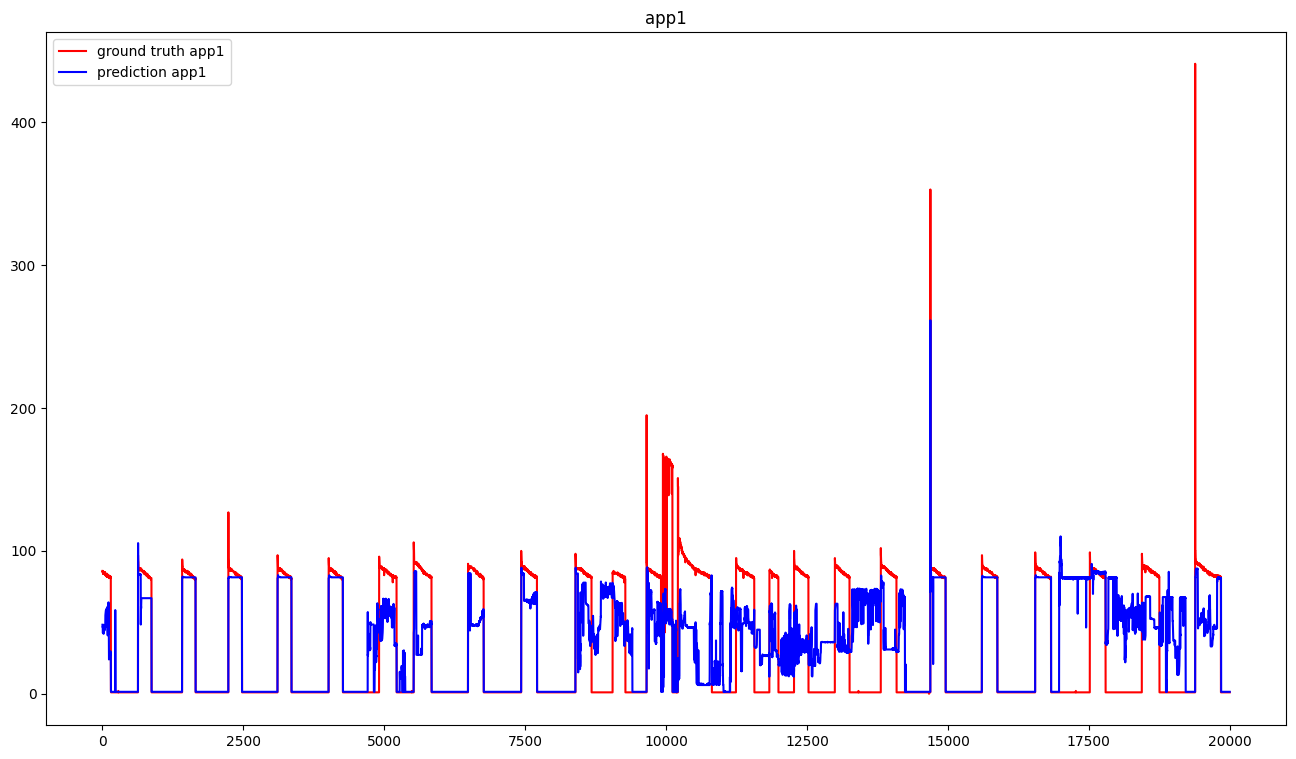

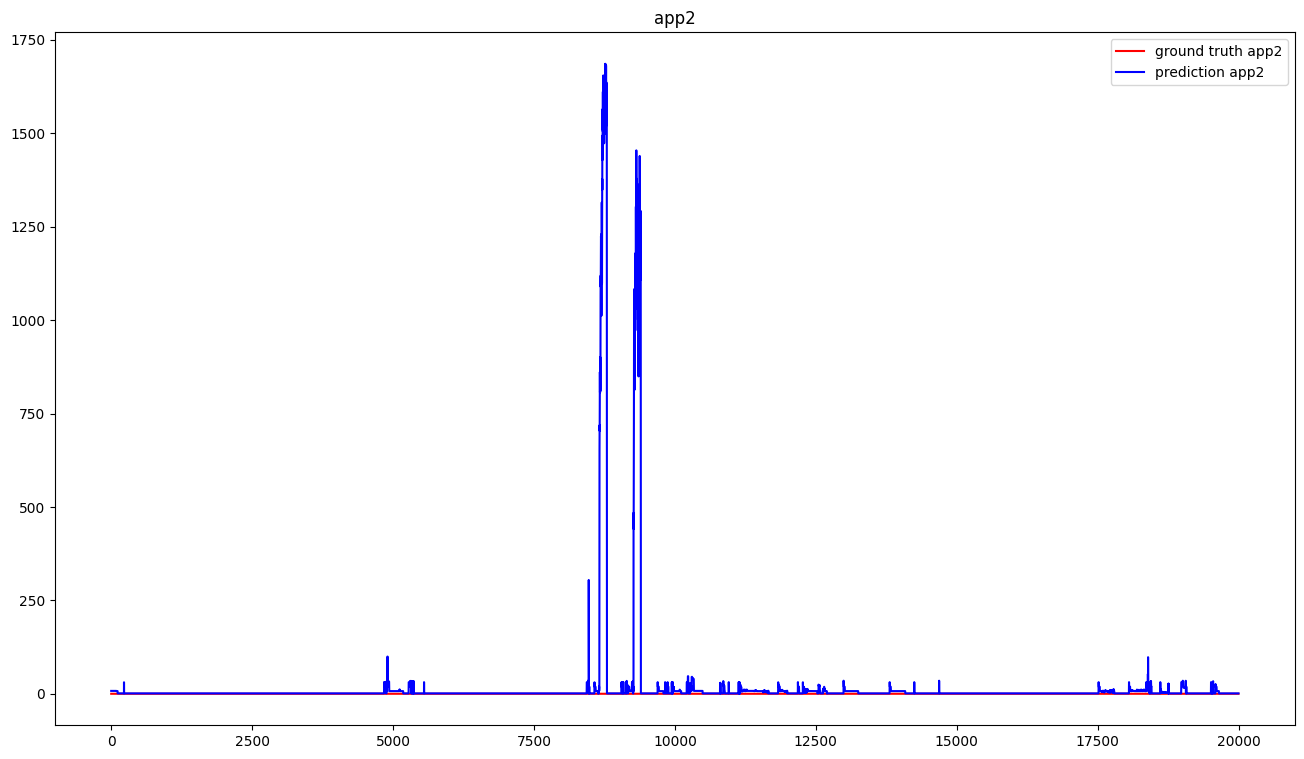

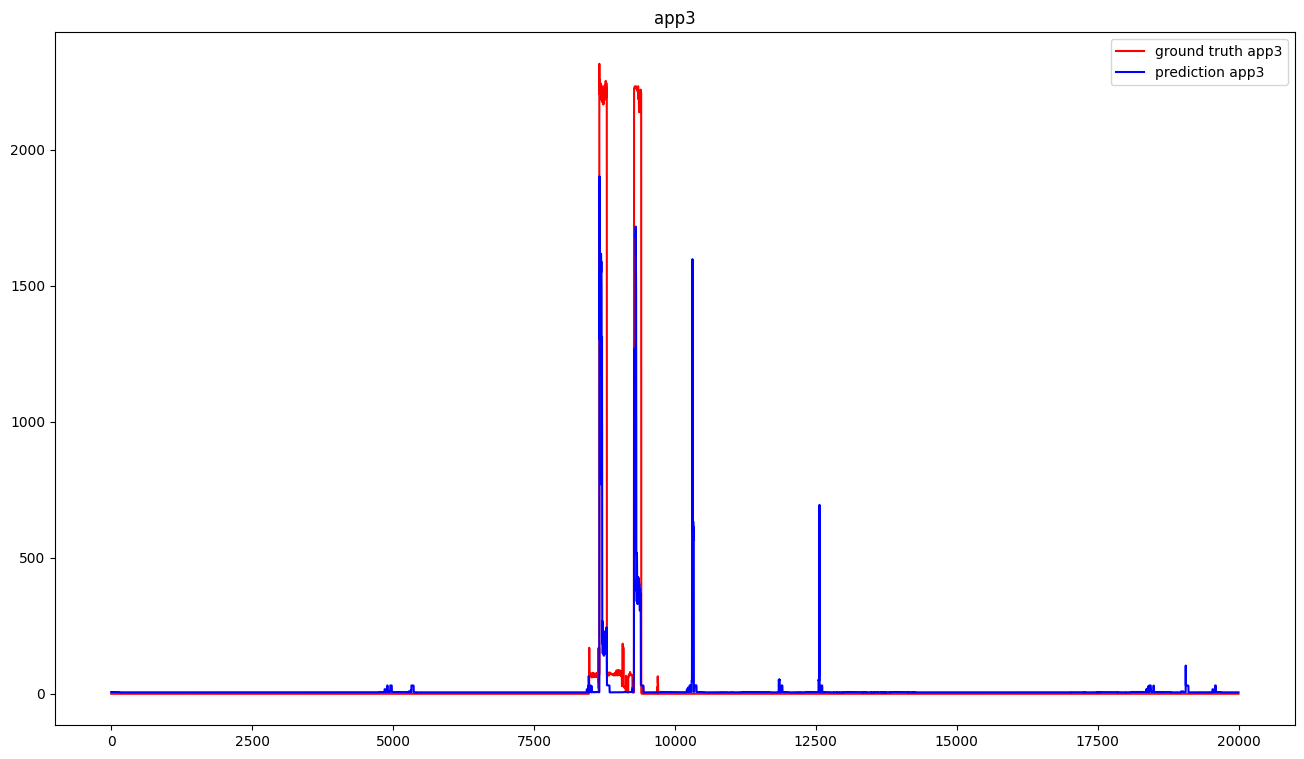

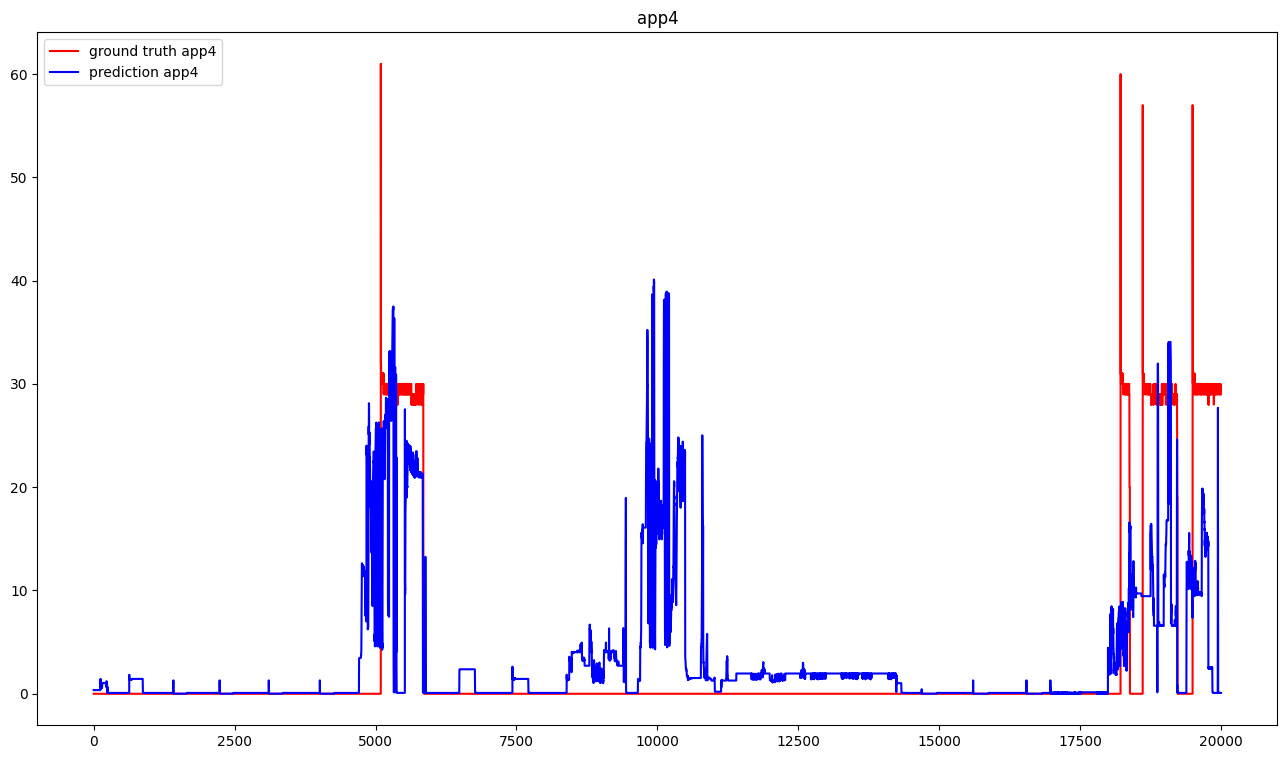

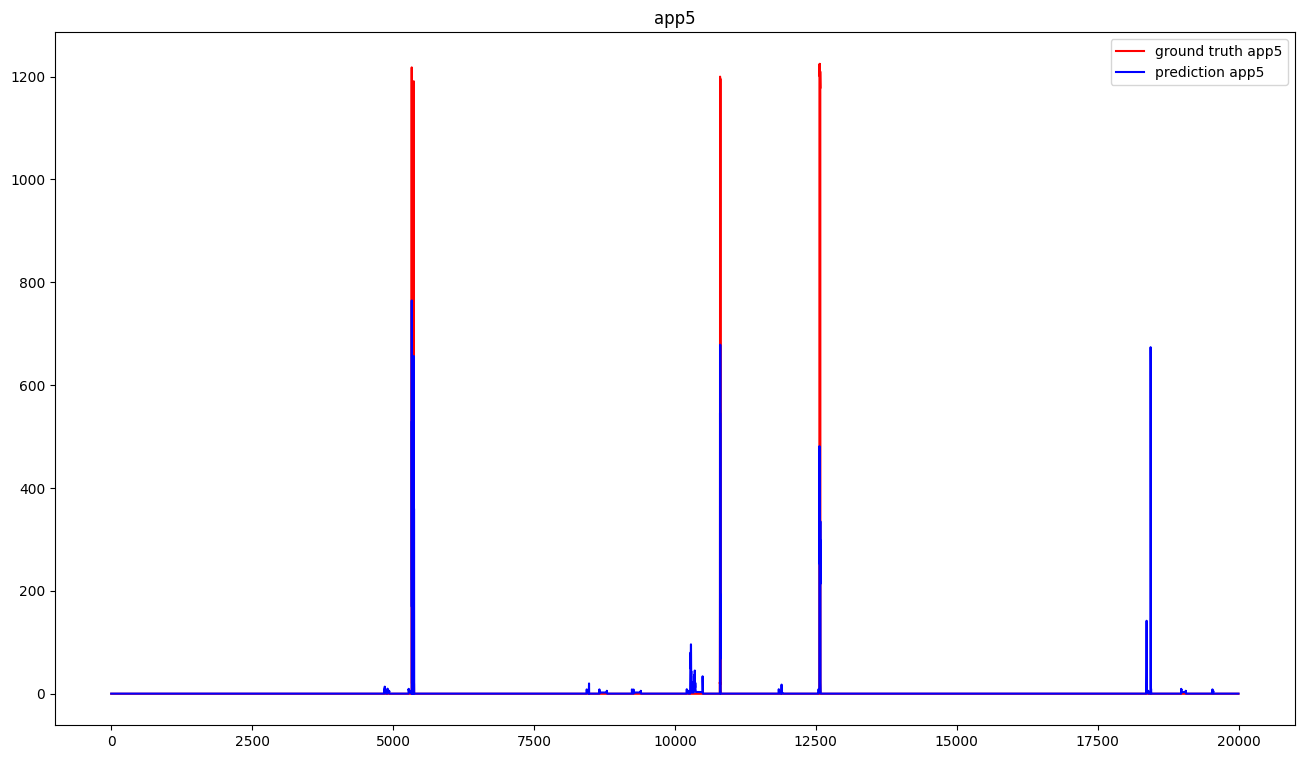

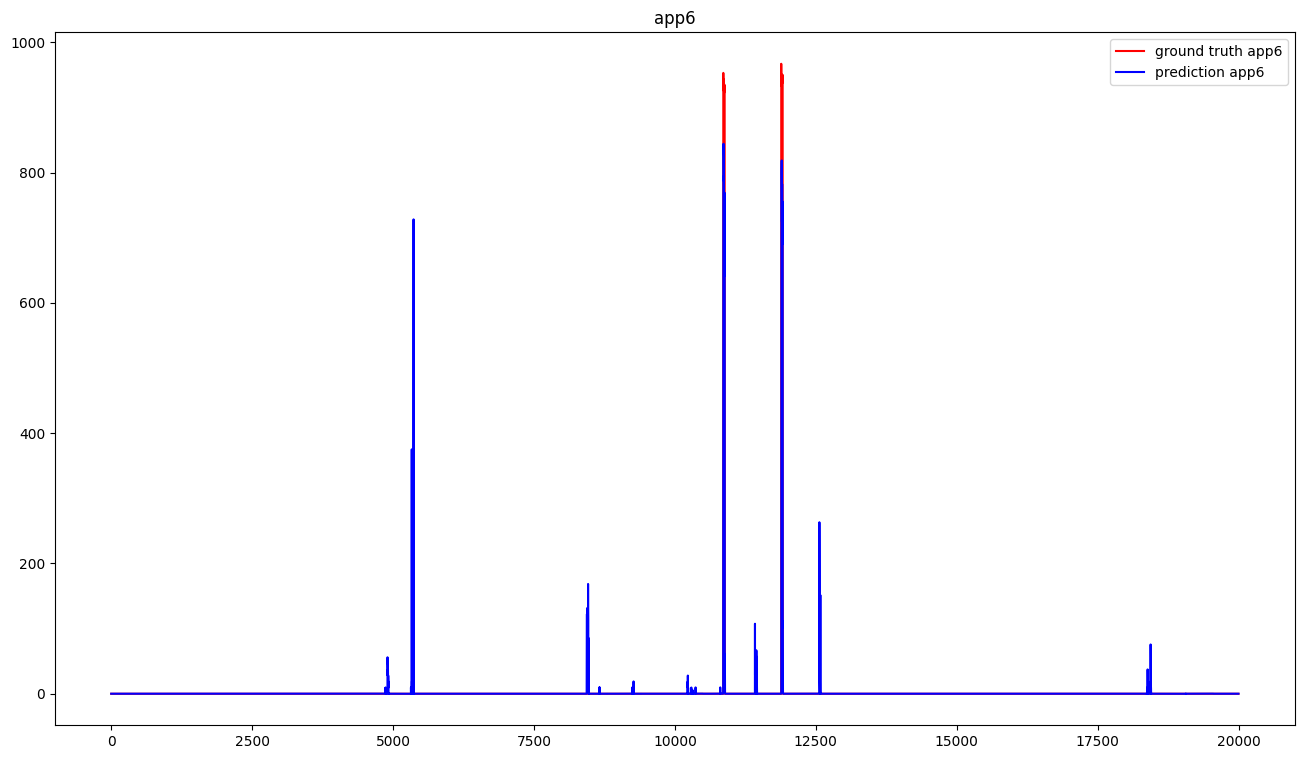

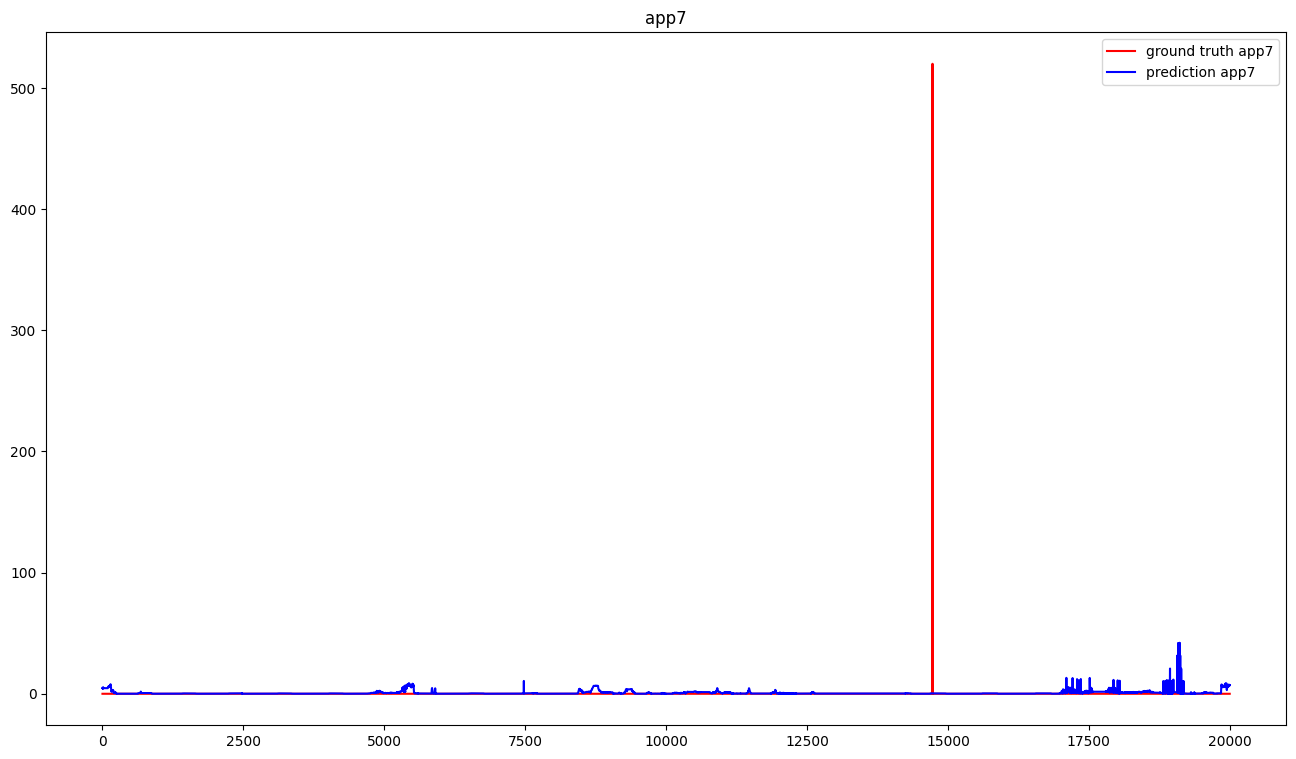

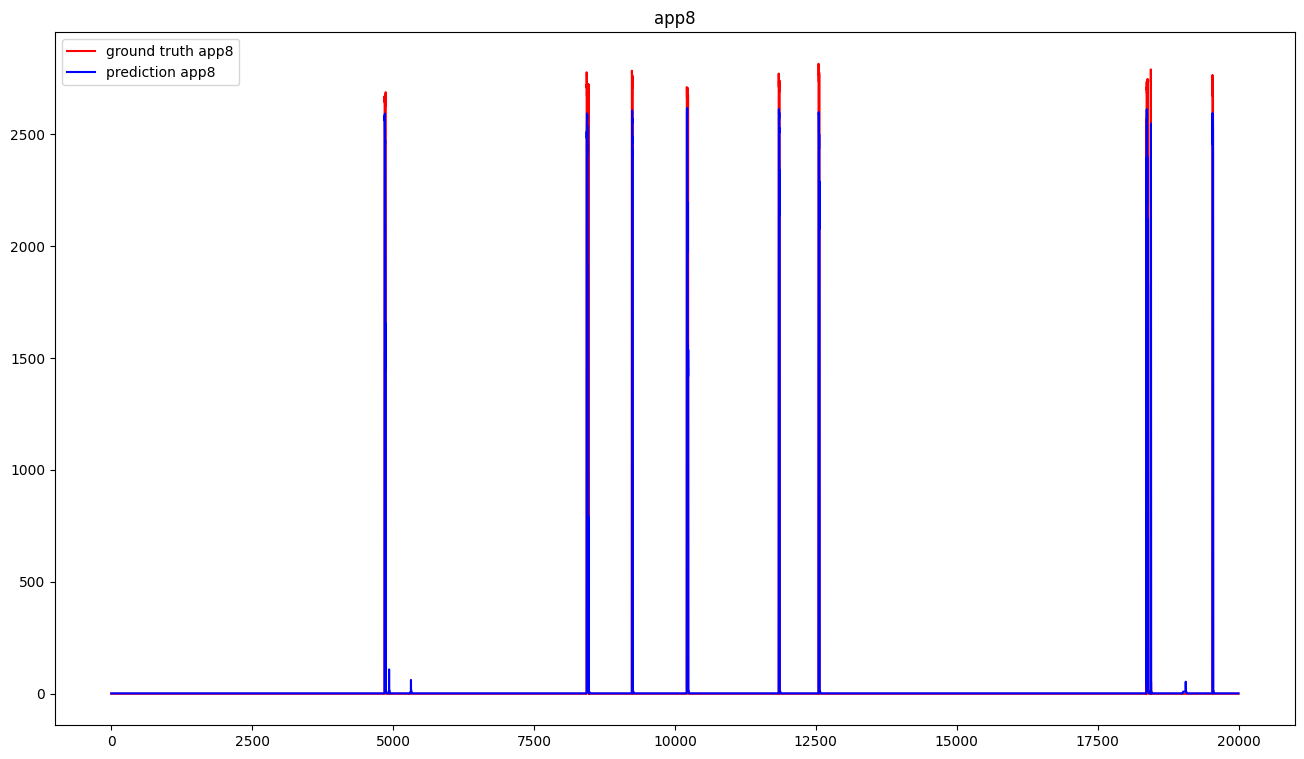

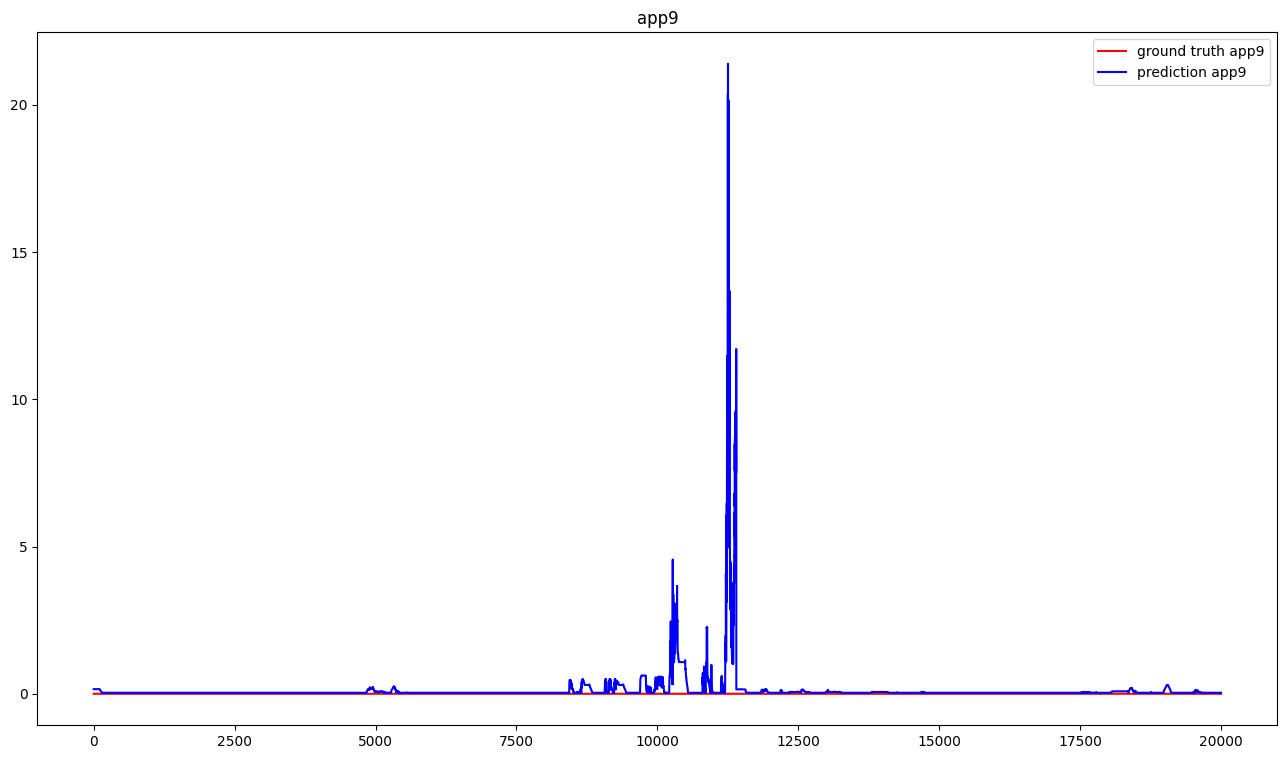

In [49]:
for i in range(9):
    plt.figure(figsize = (16,9))
    plt.plot(range(len(y_test[i])), y_test[i], color = 'r', label = f'ground truth app{i+1}')
    plt.plot(range(len(y_test[i])), pred[i], color = 'blue', label = f'prediction app{i+1}')
    plt.title(f'app{i+1}')
    plt.legend()

In [78]:
pred_all_apps = pd.DataFrame(pred).transpose()
pred_all_apps

,0,1,2,3,4,5,6,7,8
0,48.328604,7.692475,6.517556,0.357761,0.309607,0.100356,4.687685,1.939079,0.156980
1,46.816977,7.692475,6.517556,0.357761,0.309607,0.100356,5.043921,1.939079,0.157109
2,46.837770,7.692475,6.517556,0.357761,0.309607,0.100356,4.783036,1.939079,0.157429
3,47.025978,7.692475,6.517556,0.357761,0.309607,0.100356,4.445524,1.939079,0.157020
4,47.028656,7.692475,6.517556,0.357761,0.309607,0.100356,4.638299,1.939079,0.156686
...,...,...,...,...,...,...,...,...,...
19995,1.376903,1.066071,5.224987,0.085381,0.309607,0.100354,7.074981,1.939079,0.034272
19996,1.376903,1.066071,5.224987,0.085381,0.309607,0.100354,6.898162,1.939079,0.034272
19997,1.376903,1.066071,5.224987,0.085381,0.309607,0.100354,6.799392,1.939079,0.034272
19998,1.376903,1.066071,5.224987,0.085381,0.309607,0.100354,7.005391,1.939079,0.034272


In [58]:
y_groundtruth = pd.DataFrame(y_test).transpose()
y_groundtruth

,0,1,2,3,4,5,6,7,8
0,86,0,0,0,0,0,0,0,0
1,86,0,0,0,0,0,0,0,0
2,85,0,0,0,0,0,0,0,0
3,85,0,0,0,0,0,0,0,0
4,85,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
19995,1,0,0,29,0,0,0,0,0
19996,1,0,0,29,0,0,0,0,0
19997,1,0,0,29,0,0,0,0,0
19998,1,0,0,29,0,0,0,0,0


In [72]:
y_groundtruth['remain'] = X_test.reset_index()['Aggregate_t0'] - y_groundtruth.sum(axis = 1)

In [79]:
pred_all_apps['remain'] = X_test.reset_index()['Aggregate_t0'] - pred_all_apps.sum(axis = 1)

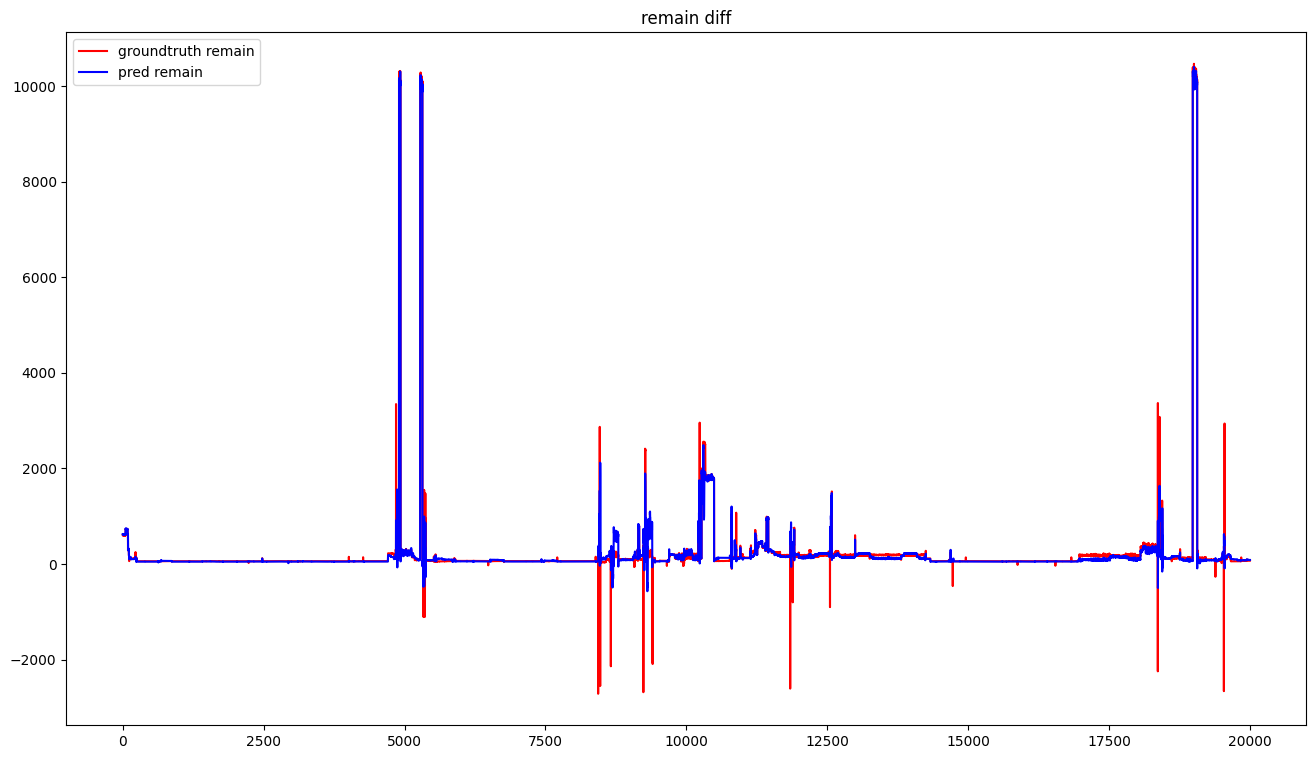

In [80]:
plt.figure(figsize = (16,9))
plt.title('remain diff')
plt.plot(y_groundtruth['remain'].to_numpy(), color = 'r', label = 'groundtruth remain')
plt.plot(pred_all_apps['remain'].to_numpy(), color = 'b', label = 'pred remain')
plt.legend()

In [62]:
from src.metrics.energy_base_metrics import Precision_energy_based, Recall_energy_based, F1_energy_based, NEP, MAE

In [86]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)
def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)
def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)
def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

In [82]:
Precision_energy_based_fixed(pred_all_apps, y_groundtruth)

0         6.574736e-01
1         2.624623e-12
2         5.309945e-01
3         3.891464e-01
4         3.553416e-01
5         7.626715e-01
6         2.336205e-05
7         8.750499e-01
8         3.680218e-10
remain    9.148161e-01
dtype: float64

In [85]:
Recall_energy_based_fixed(pred_all_apps, y_groundtruth)

0         0.678141
1         1.000000
2         0.269431
3         0.406000
4         0.304641
5         0.772734
6         0.000652
7         0.813041
8         1.000000
remain    0.897954
dtype: float64

In [96]:
F1_energy_based_fixed(pred_all_apps, y_groundtruth)

0         6.676473e-01
1         5.249247e-12
2         3.574757e-01
3         3.973945e-01
4         3.280440e-01
5         7.676700e-01
6         4.510680e-05
7         8.429066e-01
8         7.360437e-10
remain    9.063065e-01
dtype: float64

In [88]:
NEP_fixed(pred_all_apps, y_groundtruth)

0         6.751527e-01
1         3.810070e+11
2         9.685463e-01
3         1.231309e+00
4         1.248037e+00
5         4.677254e-01
6         2.888900e+01
7         3.030547e-01
8         2.717230e+09
remain    1.856599e-01
dtype: float64

In [91]:
MAE(pred_all_apps, y_groundtruth)

0         21.796157
1         19.050352
2         29.958686
3          3.683153
4          2.076109
5          1.147097
6          0.751114
7          7.175320
8          0.135862
remain    39.385918
dtype: float64